In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
OCORRENCIAS = r'C:\analise de dados\03.BaseDPEvolucaoMensalCisp.csv'
DP = r'C:\analise de dados\08.DP.csv'

df_ocorrencias = pd.read_csv(
    OCORRENCIAS,
    sep=';',
    encoding= 'iso-8859-1'
)

df_DP = pd.read_csv(
    DP

)


In [3]:
df_merge = df_ocorrencias.merge(
    df_DP,
    how='left',
    right_on='codDP',
    left_on= 'cisp'
)

df_roubo_transeunte= df_merge[[
    'cisp', 'nome', 'roubo_transeunte', 'ano', 'mes', 'regiao'
]]

df_roubo_transeunte.info()
df_roubo_transeunte['nome'].isna() #verifica erros 
df_roubo_transeunte['nome'].isnull() #verifica vazio

df_roubo_transeunte = df_roubo_transeunte.fillna('DP não informada.') #'completa' os erros 


<class 'pandas.DataFrame'>
RangeIndex: 34848 entries, 0 to 34847
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   cisp              34848 non-null  int64
 1   nome              34787 non-null  str  
 2   roubo_transeunte  34848 non-null  int64
 3   ano               34848 non-null  int64
 4   mes               34848 non-null  int64
 5   regiao            34848 non-null  str  
dtypes: int64(4), str(2)
memory usage: 1.6 MB


In [4]:
df_roubo_transeunte_agg = (
    df_roubo_transeunte.groupby('nome')['roubo_transeunte']
    .sum().reset_index().sort_values(by='roubo_transeunte', ascending=False)
)
df_roubo_transeunte_agg

,nome,roubo_transeunte
51,059ª DP - Duque de Caxias,59518
56,064ª DP - São João de Meriti,43262
30,034ª DP - Bangu,42713
64,074ª DP - Alcântara,35892
25,029ª DP - Madureira,31430
...,...,...
117,142ª DP - Cambuci,13
129,156ª DP - Santa Maria Madalena,7
76,092ª DP - Rio das Flores,5
128,155ª DP - São Sebastião do Alto,4


In [5]:
roubo_transeunte_array = np.array(df_roubo_transeunte_agg['roubo_transeunte'])

media = np.mean(roubo_transeunte_array)
mediana = np.median(roubo_transeunte_array)
desvio = np.std(roubo_transeunte_array)
max = np.max(roubo_transeunte_array)
min = np.min(roubo_transeunte_array)
amplitude = (max - min)

delta_media_mediana = (media - mediana) # -> deslocamento

q1 = np.percentile(roubo_transeunte_array, 25)
q3 = np.percentile(roubo_transeunte_array, 75)
iqr = q3 - q1
#outliers - preparação
limite_inferior = q1 - 1.5*iqr
limite_superior = q3 + 1.5*iqr
cv = (desvio/media)*100

#formato de distribuição
assimetria = df_roubo_transeunte['roubo_transeunte'].skew()
curtose = df_roubo_transeunte['roubo_transeunte'].kurtosis()



In [6]:
print('Análise - ROUBO TRANSEUNTE')
print('-'*60)
print(f'Média: {media:.2f}')
print(f'Mediana: {mediana:.2f}')
print(f'Desvio padrão: {desvio:.2f}')
print(f'Q1: {q1:.2f}')
print(f'Q2/Mediana: {mediana:.2f}')
print(f'Q3: {q3:.2f}')
print(f'IQR: {iqr:.2f}')
print(f'Amplitude: {amplitude:.2f}')
print(f'Coeficiente de Variação(CV): {cv:.2f}')
print(f'Delta Média-Mediana: {delta_media_mediana:.2f}')
print(f'Limite Inferior: {limite_inferior}')
print(f'Limite Superior: {limite_superior}')
print(f'Curtose: {curtose:.4f}')
print(f'Assimetria: {assimetria:.4f}')


Análise - ROUBO TRANSEUNTE
------------------------------------------------------------
Média: 8822.72
Mediana: 3799.50
Desvio padrão: 10972.33
Q1: 173.75
Q2/Mediana: 3799.50
Q3: 16100.50
IQR: 15926.75
Amplitude: 59515.00
Coeficiente de Variação(CV): 124.36
Delta Média-Mediana: 5023.22
Limite Inferior: -23716.375
Limite Superior: 39990.625
Curtose: 7.7882
Assimetria: 2.3693


In [7]:
df_roubo_transeunte_outliers_inf = (
    df_roubo_transeunte_agg[df_roubo_transeunte_agg['roubo_transeunte'] < limite_inferior]
)
df_roubo_transeunte_outliers_sup = (
    df_roubo_transeunte_agg[df_roubo_transeunte_agg['roubo_transeunte'] > limite_superior]
)


In [8]:
if len(df_roubo_transeunte_outliers_inf) <= 0:
    print('Não há outliers inferiores')
else:
        print(f'Há {len(df_roubo_transeunte_outliers_inf)} outliers inferiores. ')

if len(df_roubo_transeunte_outliers_sup) <= 0:
    print('Não há outliers superiores')
else:
        print(f'Há {len(df_roubo_transeunte_outliers_sup)} outliers superiores. ')

print(df_roubo_transeunte_outliers_sup)

Não há outliers inferiores
Há 3 outliers superiores. 
                            nome  roubo_transeunte
51     059ª DP - Duque de Caxias             59518
56  064ª DP - São João de Meriti             43262
30               034ª DP - Bangu             42713


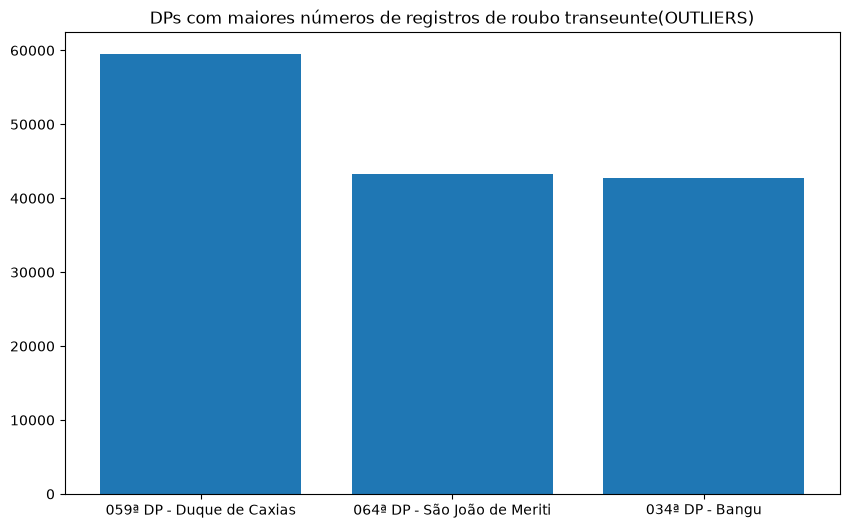

C:\Users\eduarda.castilho.SENACRJEDU\AppData\Local\Temp\ipykernel_15524\3446998169.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_roubo_transeunte_agg['roubo_transeunte'], showmeans=True, vert=False)


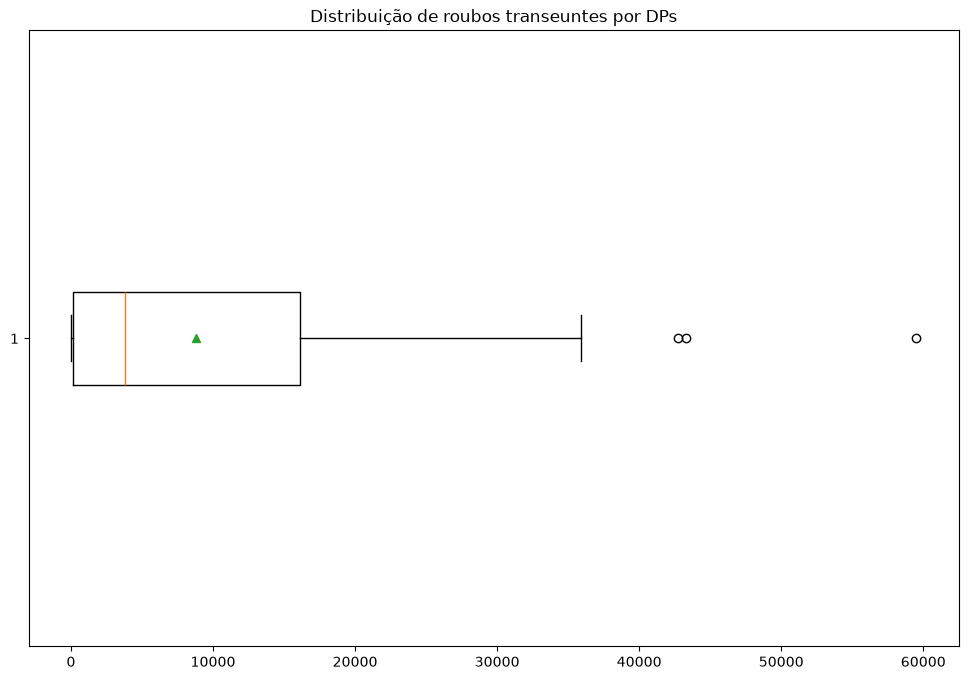

In [9]:

plt.figure(figsize=(10, 6))
plt.bar(df_roubo_transeunte_outliers_sup['nome'],
        df_roubo_transeunte_outliers_sup['roubo_transeunte'])
plt.title('DPs com maiores números de registros de roubo transeunte(OUTLIERS)')
plt.show()

plt.figure(figsize=(12, 8))
plt.boxplot(df_roubo_transeunte_agg['roubo_transeunte'], showmeans=True, vert=False)
plt.title('Distribuição de roubos transeuntes por DPs')
plt.show()

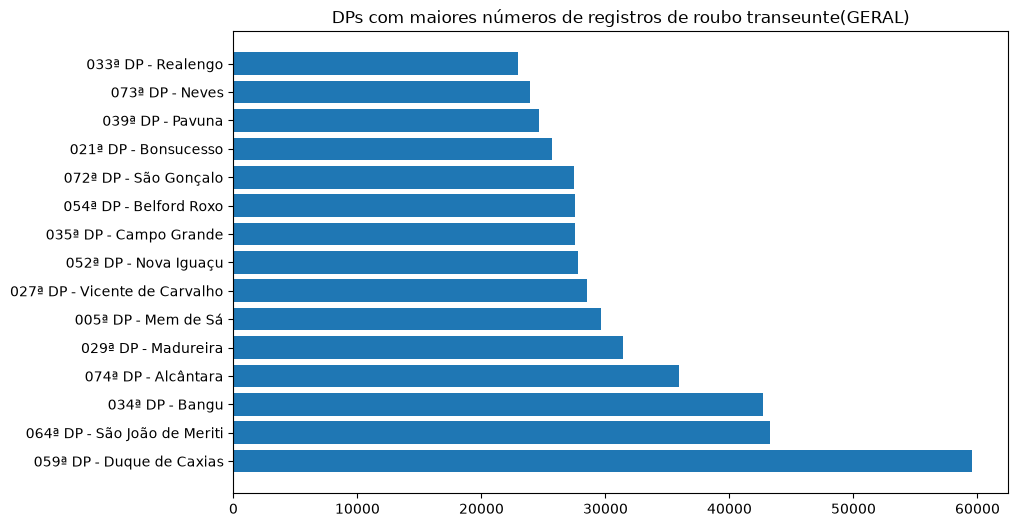

In [10]:

plt.figure(figsize=(10, 6))
df_roubo_transeunte_agg = df_roubo_transeunte_agg.iloc[0:15]
plt.barh(df_roubo_transeunte_agg['nome'],
        df_roubo_transeunte_agg['roubo_transeunte'])
plt.title('DPs com maiores números de registros de roubo transeunte(GERAL)')
plt.show()


In [11]:
df_merge = df_ocorrencias.merge(
    df_DP,
    how='left',
    right_on='codDP',
    left_on= 'cisp'
)

df_roubo_celular= df_merge[[
    'cisp', 'nome', 'roubo_celular', 'ano', 'mes', 'regiao'
]]

df_roubo_celular.info()
df_roubo_celular['nome'].isna() #verifica erros 
df_roubo_celular['nome'].isnull() #verifica vazio

df_roubo_celular = df_roubo_celular.fillna('DP não informada.') #'completa' os erros 


<class 'pandas.DataFrame'>
RangeIndex: 34848 entries, 0 to 34847
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   cisp           34848 non-null  int64
 1   nome           34787 non-null  str  
 2   roubo_celular  34848 non-null  int64
 3   ano            34848 non-null  int64
 4   mes            34848 non-null  int64
 5   regiao         34848 non-null  str  
dtypes: int64(4), str(2)
memory usage: 1.6 MB


In [12]:
df_roubo_celular_agg = (
    df_roubo_celular.groupby('nome')['roubo_celular']
    .sum().reset_index().sort_values(by='roubo_celular', ascending=False)
)
df_roubo_celular_agg

,nome,roubo_celular
51,059ª DP - Duque de Caxias,12319
56,064ª DP - São João de Meriti,9414
30,034ª DP - Bangu,8771
25,029ª DP - Madureira,7814
29,033ª DP - Realengo,7175
...,...,...
93,111ª DP - Sumidouro,2
128,155ª DP - São Sebastião do Alto,1
125,152ª DP - Duas Barras,1
130,157ª DP - Trajano de Moraes,1


In [13]:
roubo_celular_array = np.array(df_roubo_celular_agg['roubo_celular'])

mediaC = np.mean(roubo_celular_array)
medianaC = np.median(roubo_celular_array)
desvioC = np.std(roubo_celular_array)
maxC = np.max(roubo_celular_array)
minC = np.min(roubo_celular_array)
amplitudeC = (maxC - minC)

delta_media_medianaC = (mediaC - medianaC)


q1C = np.percentile(roubo_celular_array, 25)
q3C = np.percentile(roubo_celular_array, 75)
iqrC = q3C - q1C
#outliers - preparação
limite_inferiorC = q1C - 1.5*iqrC
limite_superiorC = q3C + 1.5*iqrC
cvC = (desvioC/mediaC)*100

assimetriaC = df_roubo_celular['roubo_celular'].skew()
curtoseC = df_roubo_celular['roubo_celular'].kurtosis()

In [14]:
print('Análise - ROUBO CELULAR')
print('-'*60)
print(f'Média: {mediaC:.2f}')
print(f'Mediana: {medianaC:.2f}')
print(f'Desvio padrão: {desvioC:.2f}')
print(f'Desvio padrão: {desvio:.2f}')
print(f'Q1: {q1C:.2f}')
print(f'Q2/Mediana: {medianaC:.2f}')
print(f'Q3: {q3C:.2f}')
print(f'IQR: {iqrC:.2f}')
print(f'Máximo: {maxC}')
print(f'Amplitude: {amplitudeC:.2f}')
print(f'Coeficiente de Variação(CV): {cvC:.2f}')
print(f'Delta Média-Mediana: {delta_media_medianaC:.2f}')
print(f'Limite Inferior: {limite_inferiorC}')
print(f'Limite Superior: {limite_superiorC}')
print(f'Curtose: {curtoseC:.4f}')
print(f'Assimetria: {assimetriaC:.4f}')


Análise - ROUBO CELULAR
------------------------------------------------------------
Média: 2011.96
Mediana: 715.00
Desvio padrão: 2466.58
Desvio padrão: 10972.33
Q1: 43.25
Q2/Mediana: 715.00
Q3: 3746.50
IQR: 3703.25
Máximo: 12319
Amplitude: 12319.00
Coeficiente de Variação(CV): 122.60
Delta Média-Mediana: 1296.96
Limite Inferior: -5511.625
Limite Superior: 9301.375
Curtose: 18.8006
Assimetria: 3.3719


In [15]:
df_roubo_celular_outliers_inf = (
    df_roubo_celular_agg[df_roubo_celular_agg['roubo_celular'] < limite_inferiorC]
)
df_roubo_celular_outliers_sup = (
    df_roubo_celular_agg[df_roubo_celular_agg['roubo_celular'] > limite_superiorC]
)

if len(df_roubo_celular_outliers_inf) <= 0:
    print('Não há outliers inferiores')
else:
    print(f'Há {len(df_roubo_celular_outliers_inf)} outliers inferiores. ')

if len(df_roubo_celular_outliers_sup) <= 0:
    print('Não há outliers superiores')
else:
    print(f'Há {len(df_roubo_celular_outliers_sup)} outliers superiores. ')

print(df_roubo_celular_outliers_sup)

Não há outliers inferiores
Há 2 outliers superiores. 
                            nome  roubo_celular
51     059ª DP - Duque de Caxias          12319
56  064ª DP - São João de Meriti           9414


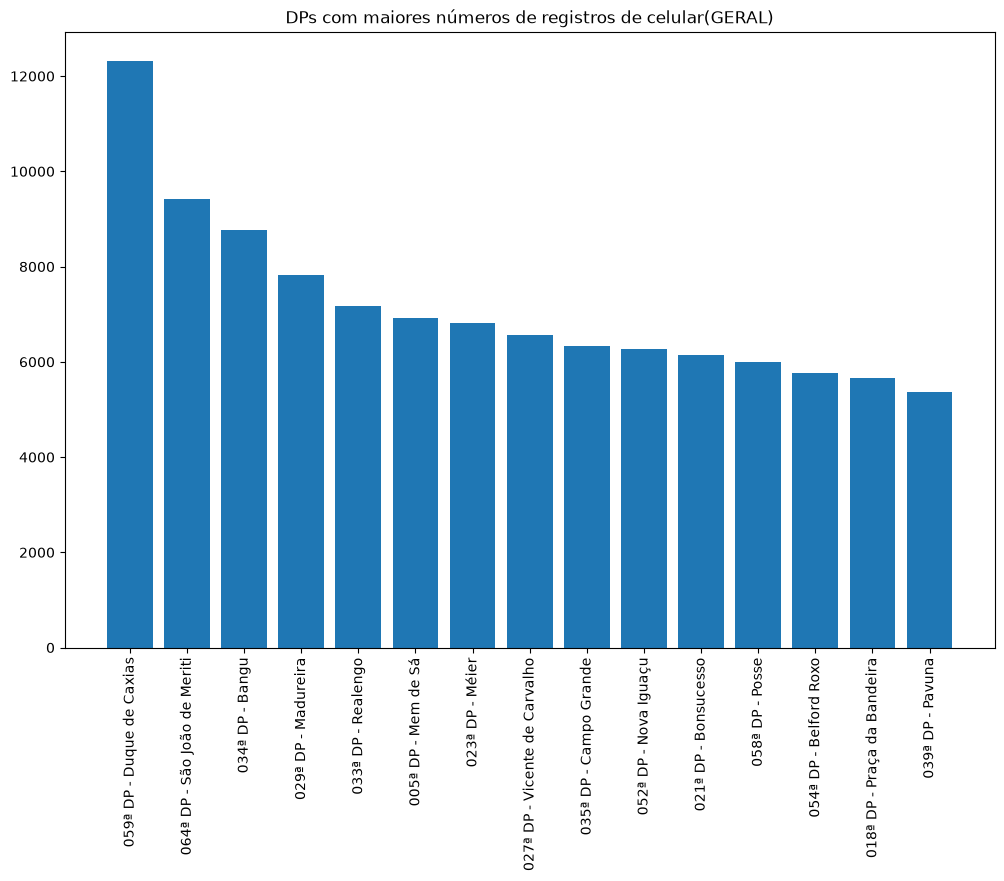

C:\Users\eduarda.castilho.SENACRJEDU\AppData\Local\Temp\ipykernel_15524\3181881482.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_roubo_celular_agg['roubo_celular'], showmeans=True, vert=False)


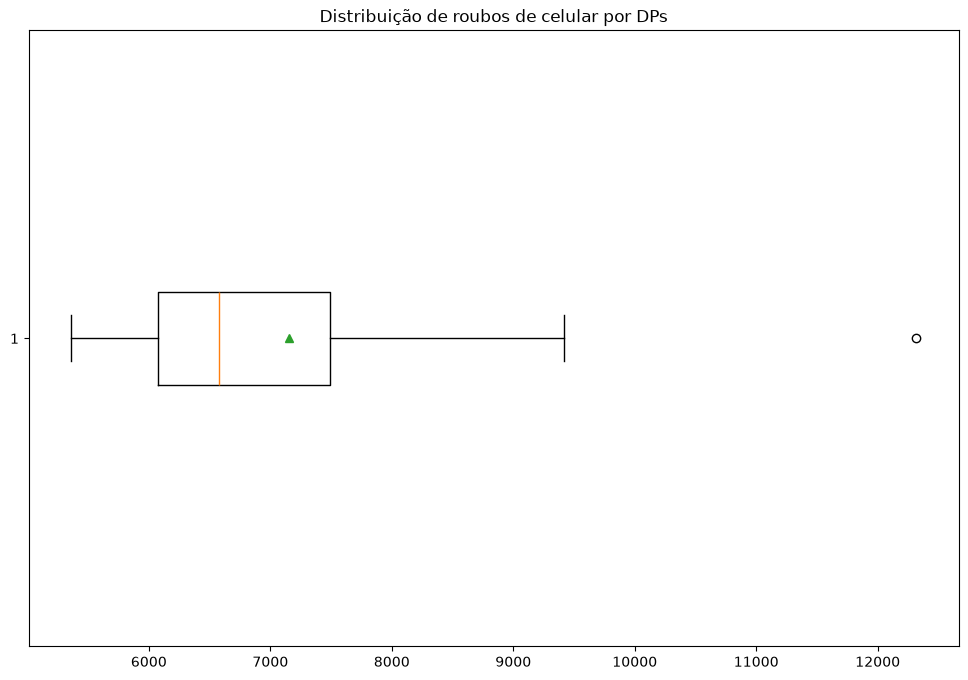

In [16]:
plt.figure(figsize=(12, 8))
df_roubo_celular_agg = df_roubo_celular_agg.iloc[0:15]
plt.xticks(rotation=90)
plt.bar(df_roubo_celular_agg['nome'],
        df_roubo_celular_agg['roubo_celular'])
plt.title('DPs com maiores números de registros de celular(GERAL)')
plt.show()

plt.figure(figsize=(12, 8))
plt.boxplot(df_roubo_celular_agg['roubo_celular'], showmeans=True, vert=False)
plt.title('Distribuição de roubos de celular por DPs')
plt.show()

In [19]:

df_roubo_celular_outlier_mes = (
    df_roubo_celular.groupby('mes')['roubo_celular']
    .sum().reset_index().sort_values(by='roubo_celular', ascending=False)
)
df_roubo_celular_outlier_mes

,mes,roubo_celular
4,5,24819
6,7,24783
2,3,24520
5,6,24285
3,4,23313
9,10,23279
0,1,22988
7,8,22963
8,9,22492
10,11,21900
